## Setup

Import TensorFlow and other necessary libraries:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential



ModuleNotFoundError: No module named 'tensorflow'

## Download and explore the dataset

Hướng dẫn này sử dụng một tập dữ liệu gồm khoảng 3.700 bức ảnh về hoa. Tập dữ liệu này bao gồm năm thư mục con, mỗi thư mục tương ứng với một lớp (loại hoa):
```
flower_photo/
  daisy/
  dandelion/
  roses/
  sunflowers/
  tulips/
```

In [ ]:
import pathlib

# Tải dataset
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz


In [ ]:

# Đặt đường dẫn chính xác
data_dir = pathlib.Path('/content/flower_photos')

Sau khi tải xuống, bạn sẽ có một bản sao của tập dữ liệu. Tổng cộng có 3.670 hình ảnh

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Tổng số ảnh:", image_count)

Tổng số ảnh: 3670


1 vài bức ảnh của roses

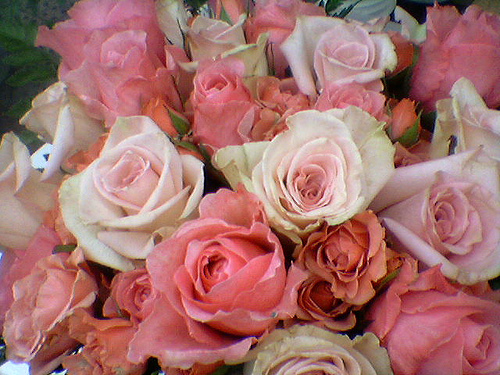

In [ ]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

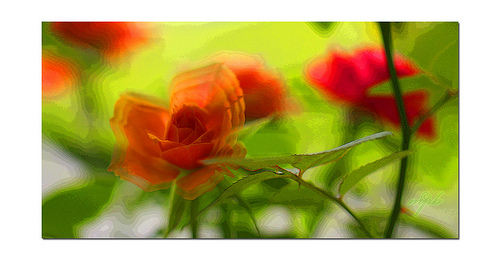

In [ ]:
PIL.Image.open(str(roses[1]))

và 1 vài tulips:

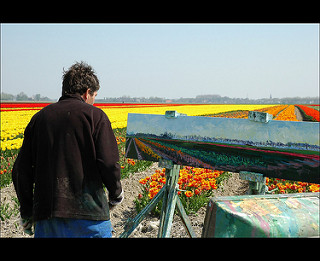

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

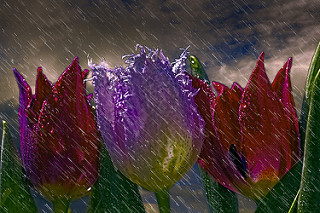

In [ ]:
PIL.Image.open(str(tulips[1]))

## Tải dữ liệu bằng tiện ích của Keras

Tiếp theo, hãy tải các hình ảnh này từ đĩa bằng cách sử dụng tiện ích tiện lợi tf.keras.utils.image_dataset_from_directory. Công cụ này sẽ giúp bạn chuyển từ một thư mục chứa hình ảnh trên đĩa sang một đối tượng tf.data.Dataset chỉ với vài dòng mã. Nếu muốn, bạn cũng có thể tự viết mã tải dữ liệu của riêng mình từ đầu bằng cách truy cập hướng dẫn Tải và tiền xử lý hình ảnh.

##Tạo 1 dataset
Định nghĩa một số tham số cho bộ tải dữ liệu:

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

Việc sử dụng tập xác thực (validation) là một thói quen tốt khi phát triển mô hình. Hãy sử dụng 80% số hình ảnh để huấn luyện và 20% để xác thực.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Bạn có thể tìm thấy tên các lớp trong thuộc tính class_names của các tập dữ liệu này. Chúng tương ứng với tên các thư mục được sắp xếp theo thứ tự bảng chữ cái

In [ ]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


##Trực quan hóa dữ liệu

Dưới đây là chín hình ảnh đầu tiên từ tập dữ liệu huấn luyện:

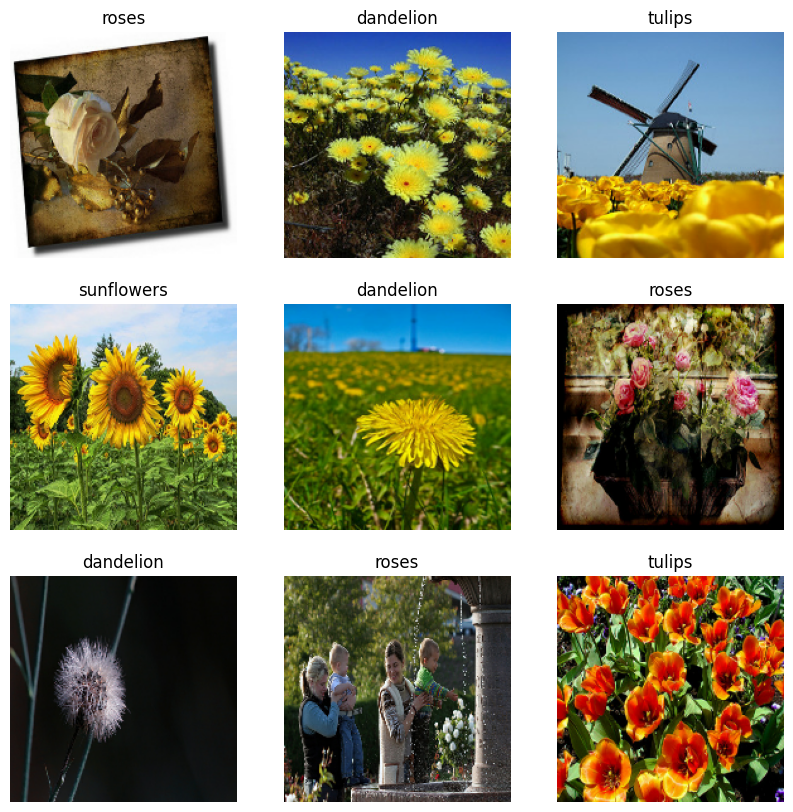

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Bạn sẽ truyền các tập dữ liệu này vào phương thức Model.fit của Keras để huấn luyện ở phần sau của hướng dẫn này. Nếu muốn, bạn cũng có thể duyệt thủ công qua tập dữ liệu và lấy ra từng lô (batch) hình ảnh:

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


image_batch là một tensor có dạng (32, 180, 180, 3). Đây là một lô gồm 32 ảnh, mỗi ảnh có kích thước 180x180x3 (trong đó chiều cuối cùng đại diện cho các kênh màu RGB).
label_batch là một tensor có dạng (32,), đây là các nhãn tương ứng với 32 ảnh đó.

Bạn có thể gọi .numpy() trên các tensor image_batch và label_batch để chuyển chúng thành đối tượng numpy.ndarray.

## Cấu hình dataset để tăng hiệu năng

Khi tải dữ liệu từ đĩa, bạn nên sử dụng kỹ thuật prefetching có bộ đệm (buffered prefetching) để dữ liệu được load song song với quá trình huấn luyện, tránh tình trạng I/O làm gián đoạn (blocking) quá trình học.

Hai phương pháp quan trọng bạn nên dùng khi chuẩn bị dữ liệu là:

- `Dataset.cache` Phương pháp này giúp lưu trữ dữ liệu đã load vào bộ nhớ RAM sau lần chạy đầu tiên. Nhờ vậy, khi huấn luyện qua các epoch tiếp theo, dữ liệu sẽ không phải tải lại từ đĩa, giúp giảm thiểu tắc nghẽn do truy xuất đĩa. Nếu dữ liệu quá lớn để chứa trong RAM, bạn cũng có thể dùng cache() để tạo cache trên đĩa, vẫn cải thiện hiệu năng đáng kể.
- `Dataset.prefetch`Phương pháp này cho phép chuẩn bị (tiền xử lý) dữ liệu trong khi mô hình đang huấn luyện trên batch trước đó, giúp tận dụng tối đa tài nguyên CPU và GPU, giảm thời gian chờ đợi dữ liệu.

Bạn có thể tham khảo thêm về cách sử dụng hai phương pháp này, cũng như các cách tạo cache trên đĩa trong phần Prefetching của hướng dẫn Better performance with the tf.data API (bằng tiếng Anh).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

##Chuẩn hóa dữ liệu

Các giá trị kênh RGB hiện đang nằm trong khoảng từ 0 đến 255. Điều này không lý tưởng cho mạng neural; nói chung, bạn nên đưa các giá trị đầu vào về phạm vi nhỏ hơn.

Ở đây, bạn sẽ chuẩn hóa (standardize) các giá trị để nằm trong khoảng từ 0 đến 1 bằng cách sử dụng lớp `tf.keras.layers.Rescaling`.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

Có hai cách để sử dụng lớp này. Bạn có thể áp dụng nó cho dataset bằng cách gọi `Dataset.map`:

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


Hoặc bạn có thể đưa lớp này vào trong phần định nghĩa mô hình của bạn, cách này giúp đơn giản hóa việc triển khai. Ở đây, hãy sử dụng cách thứ hai.

Lưu ý: Trước đó bạn đã thay đổi kích thước ảnh bằng cách sử dụng tham số image_size của `tf.keras.utils`.`image_dataset_from_directory`. Nếu bạn muốn đưa luôn logic thay đổi kích thước ảnh vào trong mô hình, bạn có thể sử dụng lớp `tf.keras.layers.Resizing`.

##Mô hình Keras cơ bản
**Tạo mô hình**

Mô hình Keras Sequential bao gồm ba khối convolution (lớp tf.keras.layers.Conv2D), mỗi khối có một lớp max pooling (tf.keras.layers.MaxPooling2D). Trên cùng là một lớp fully-connected (tf.keras.layers.Dense) với 128 đơn vị (units), sử dụng hàm kích hoạt ReLU ('relu'). Mô hình này chưa được tối ưu để đạt độ chính xác cao; mục đích của bài hướng dẫn là để minh họa cách tiếp cận tiêu chuẩn.

In [ ]:
# Xác định số lớp phân loại dựa trên số tên lớp
num_classes = len(class_names)

# Tạo mô hình Sequential (xếp chồng các layer theo tuần tự)
model = Sequential([
    # Chuẩn hóa giá trị pixel về khoảng [0,1] bằng cách chia 255
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    # input_shape: (chiều cao ảnh, chiều rộng ảnh, 3 kênh màu RGB)

    # Layer Conv2D đầu tiên với:
    # - 16 filters (kernel)
    # - Kích thước kernel 3x3
    # - Padding 'same' giữ nguyên kích thước không gian
    # - Hàm kích hoạt ReLU
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # Layer MaxPooling2D giảm kích thước không gian bằng cách lấy giá trị lớn nhất
    # Mặc định pool_size=(2,2) và strides=2 → giảm 1 nửa kích thước
    layers.MaxPooling2D(),

    # Layer Conv2D thứ hai với 32 filters
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Layer Conv2D thứ ba với 64 filters
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Chuyển đổi tensor 3D (height, width, channels) thành 1D vector để đưa vào Dense
    layers.Flatten(),

    # Layer Dense (fully-connected) với 128 neuron và ReLU activation
    layers.Dense(128, activation='relu'),

    # Layer Dense đầu ra với số neuron = số lớp cần phân loại
    # Không dùng activation để có thể dùng với loss hàm softmax sau này
    layers.Dense(num_classes)
])

##Biên dịch model

Trong bài hướng dẫn này, hãy chọn bộ tối ưu `tf.keras.optimizers.Adam` và hàm mất mát `tf.keras.losses.SparseCategoricalCrossentropy`. Để xem độ chính xác (accuracy) trên tập huấn luyện và tập kiểm tra sau mỗi epoch, bạn hãy truyền tham số metrics vào hàm `Model.compile`.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

##Model summary


Xem tất cả các lớp trong mạng bằng cách sử dụng phương thức Model.summary của Keras:

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

##Train model

Huấn luyện mô hình trong 10 epoch bằng phương thức Model.fit của Keras:

In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4074 - loss: 1.4904 - val_accuracy: 0.5477 - val_loss: 1.0858
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 977ms/step - accuracy: 0.6319 - loss: 0.9489 - val_accuracy: 0.6185 - val_loss: 0.9649
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 980ms/step - accuracy: 0.7296 - loss: 0.7350 - val_accuracy: 0.6417 - val_loss: 0.8991
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 980ms/step - accuracy: 0.8319 - loss: 0.4863 - val_accuracy: 0.6499 - val_loss: 0.9232
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 983ms/step - accuracy: 0.9126 - loss: 0.2762 - val_accuracy: 0.6526 - val_loss: 1.0705
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 91s 992ms/step - accuracy: 0.9595 - loss: 0.1516 - val_accuracy: 0.6744 - val_loss: 1.1415
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 993ms/step - accuracy: 0.9822 - loss: 0.0884 - val_accuracy: 0.6703 - val_loss: 1.2704
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 993ms/step - accuracy: 0.9838 - loss: 0.0636 - val_accu

##Trực quan hóa kết quả huấn luyện

Tạo biểu đồ cho giá trị loss và accuracy trên tập huấn luyện và tập kiểm tra:


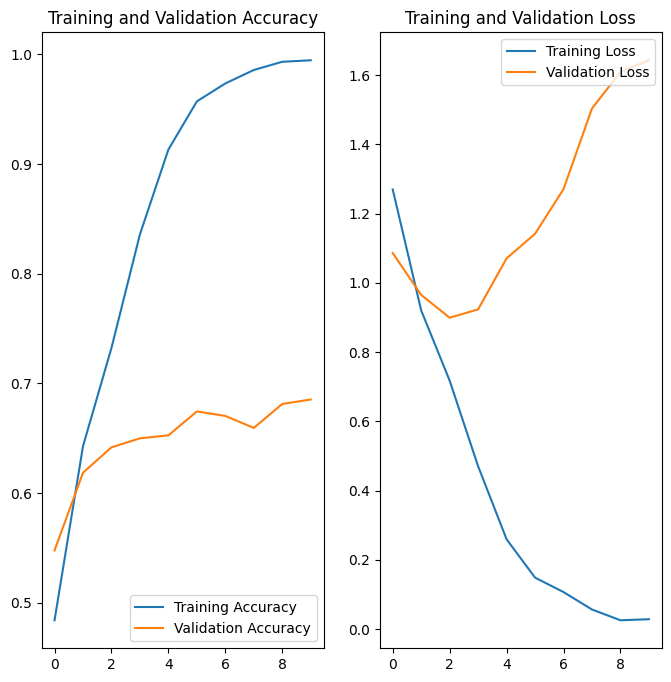

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Các biểu đồ cho thấy độ chính xác trên tập huấn luyện và tập kiểm tra chênh lệch khá lớn, và mô hình chỉ đạt khoảng 60% độ chính xác trên tập kiểm tra.

Các phần tiếp theo của bài hướng dẫn sẽ chỉ ra cách kiểm tra nguyên nhân vấn đề và cách cải thiện hiệu suất tổng thể của mô hình.

## Quá khớp

Trong các biểu đồ ở trên, độ chính xác trên tập huấn luyện tăng dần theo thời gian, trong khi độ chính xác trên tập kiểm tra dừng lại khoảng 60% trong quá trình huấn luyện. Ngoài ra, sự chênh lệch đáng kể giữa độ chính xác trên tập huấn luyện và tập kiểm tra là dấu hiệu của hiện tượng overfitting.

Khi số lượng dữ liệu huấn luyện nhỏ, mô hình đôi khi học theo các nhiễu hoặc chi tiết không mong muốn từ các ví dụ huấn luyện — đến mức ảnh hưởng tiêu cực đến hiệu suất của mô hình trên dữ liệu mới. Hiện tượng này được gọi là overfitting. Nó có nghĩa là mô hình sẽ gặp khó khăn khi tổng quát hóa trên bộ dữ liệu mới.

Có nhiều cách để chống lại hiện tượng overfitting trong quá trình huấn luyện. Trong bài hướng dẫn này, bạn sẽ sử dụng data augmentation và thêm dropout vào mô hình của mình.

##Tăng cường dữ liệu


Overfitting thường xảy ra khi số lượng ví dụ trong tập huấn luyện quá ít. Data augmentation là phương pháp tạo ra thêm dữ liệu huấn luyện mới từ các ví dụ hiện có bằng cách áp dụng các biến đổi ngẫu nhiên để tạo ra các hình ảnh trông thật và hợp lý. Cách làm này giúp mô hình được tiếp xúc với nhiều khía cạnh khác nhau của dữ liệu, từ đó cải thiện khả năng tổng quát hóa.

Bạn sẽ thực hiện data augmentation bằng cách sử dụng các lớp tiền xử lý của Keras sau: tf.keras.layers.RandomFlip, tf.keras.layers.RandomRotation, và tf.keras.layers.RandomZoom. Những lớp này có thể được đưa trực tiếp vào trong mô hình như các lớp khác và chạy trên GPU.

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

Trực quan hóa một vài ví dụ được tăng cường dữ liệu bằng cách áp dụng data augmentation nhiều lần trên cùng một ảnh:

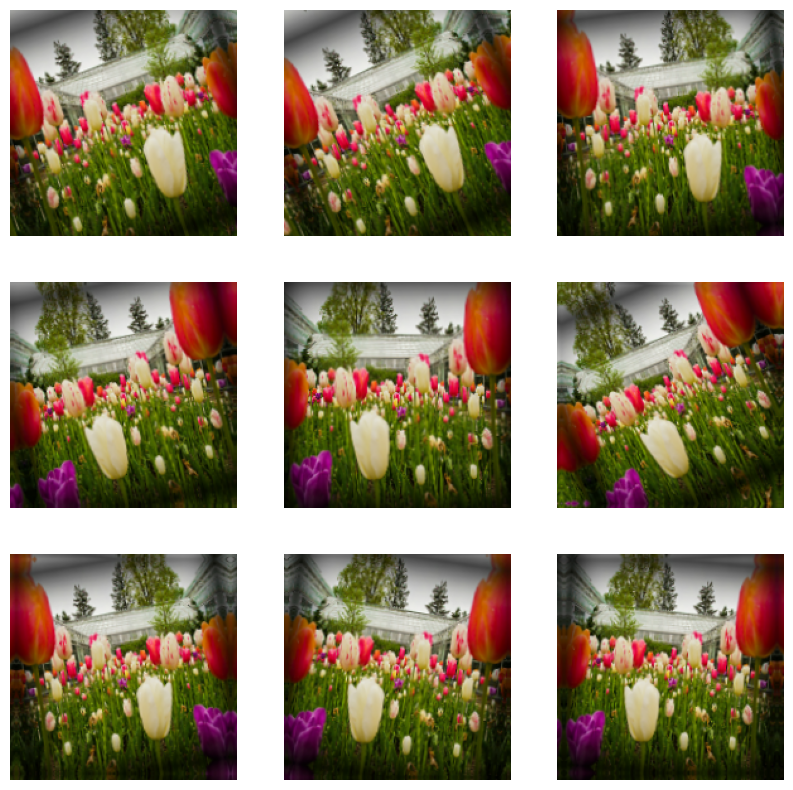

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Bạn sẽ thêm bước tăng cường dữ liệu vào mô hình trước khi huấn luyện trong bước tiếp theo.

##Dropout
Một kỹ thuật khác để giảm hiện tượng overfitting là thêm regularization dropout vào mạng.

Khi bạn áp dụng dropout cho một lớp, nó sẽ ngẫu nhiên loại bỏ (bằng cách đặt giá trị kích hoạt thành 0) một số đơn vị đầu ra của lớp đó trong quá trình huấn luyện. Dropout nhận vào một giá trị phân số, ví dụ như 0.1, 0.2, 0.4,... Tương ứng với việc ngẫu nhiên loại bỏ 10%, 20% hoặc 40% số đơn vị đầu ra của lớp được áp dụng.

Hãy tạo một mạng neural mới với lớp tf.keras.layers.Dropout, rồi huấn luyện mô hình này bằng dữ liệu ảnh đã được tăng cường (augmented images):

In [ ]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

##Biên dịch và train mô hình

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.3358 - loss: 1.5578 - val_accuracy: 0.5422 - val_loss: 1.1173
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.5531 - loss: 1.0804 - val_accuracy: 0.5531 - val_loss: 1.1258
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.6395 - loss: 0.9494 - val_accuracy: 0.6512 - val_loss: 0.8975
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.6578 - loss: 0.8976 - val_accuracy: 0.6063 - val_loss: 0.9540
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.6727 - loss: 0.8597 - val_accuracy: 0.6757 - val_loss: 0.8519
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.7061 - loss: 0.7457 - val_accuracy: 0.6785 - val_loss: 0.7958
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7260 - loss: 0.7316 - val_accuracy: 0.7030 - val_loss: 0.7674
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7376 - loss: 0.6955 - val_accuracy: 0.7193 - v

##Trực quan hóa kết quả huấn luyện

Sau khi áp dụng tăng cường dữ liệu và tf.keras.layers.Dropout, hiện tượng overfitting đã giảm so với trước, và độ chính xác trên tập huấn luyện và tập kiểm tra gần nhau hơn:

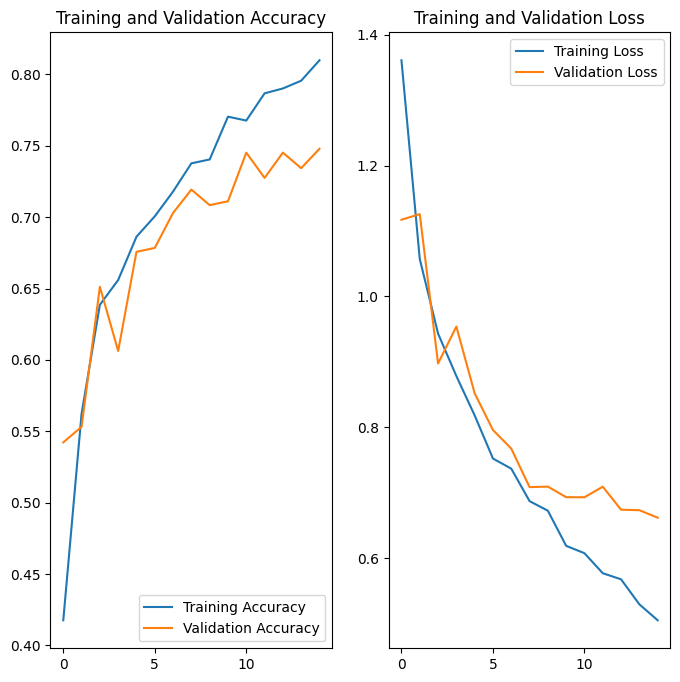

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Dự đoán trên dữ liệu mới

Sử dụng mô hình của bạn để phân loại một ảnh chưa từng xuất hiện trong tập huấn luyện hoặc tập kiểm tra.

Lưu ý: Các lớp data augmentation và dropout sẽ không hoạt động trong thời gian suy luận (inference).

In [ ]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

117948/117948 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
This image most likely belongs to sunflowers with a 99.55 percent confidence.


##Sử dụng TensorFlow Lite

TensorFlow Lite là một bộ công cụ giúp phát triển machine learning trên thiết bị, cho phép các nhà phát triển chạy mô hình của họ trên các thiết bị di động, nhúng và thiết bị biên (edge devices).

##Chuyển đổi mô hình Keras Sequential sang mô hình TensorFlow Lite

Để sử dụng mô hình đã huấn luyện trong các ứng dụng chạy trên thiết bị, trước tiên bạn cần chuyển đổi nó sang định dạng mô hình nhỏ hơn và hiệu quả hơn gọi là mô hình TensorFlow Lite.

Trong ví dụ này, lấy mô hình Keras Sequential đã huấn luyện và sử dụng tf.lite.TFLiteConverter.from_keras_model để tạo ra mô hình TensorFlow Lite:

In [ ]:
# Convert the model.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpycl3zujj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137193399315216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399313872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399311568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399317712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399310224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399312912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399312144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399316176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137193399311376: TensorSpec(shape=(), dtype=tf.resource, name=None)


Mô hình TensorFlow Lite mà bạn đã lưu ở bước trước có thể chứa nhiều chữ ký hàm (function signatures) khác nhau. API chuyển đổi mô hình Keras sẽ tự động sử dụng chữ ký mặc định. Tìm hiểu thêm về các chữ ký trong TensorFlow Lite.

##Chạy mô hình TensorFlow Lite
Bạn có thể truy cập các chữ ký (signatures) của mô hình TensorFlow Lite đã lưu trong Python thông qua lớp tf.lite.Interpreter.

Tải mô hình bằng Interpreter:

In [ ]:
TF_MODEL_FILE_PATH = 'model.tflite' # The default path to the saved TensorFlow Lite model

interpreter = tf.lite.Interpreter(model_path=TF_MODEL_FILE_PATH)

In danh sách các chữ ký (signatures) từ mô hình đã chuyển đổi để lấy tên của các đầu vào (và đầu ra):

In [ ]:
interpreter.get_signature_list()

{'serving_default': {'inputs': ['keras_tensor_15'], 'outputs': ['output_0']}}

Trong ví dụ này, bạn có một chữ ký mặc định gọi là serving_default. Ngoài ra, tên của phần đầu vào là 'sequential_1_input', trong khi phần đầu ra có tên là 'outputs'. Bạn có thể tra cứu các tên lớp đầu và cuối của mô hình Keras khi chạy Model.summary, như đã trình bày trước đó trong hướng dẫn này.

Bây giờ, bạn có thể kiểm tra mô hình TensorFlow Lite đã tải bằng cách thực hiện suy luận (inference) trên một ảnh mẫu, sử dụng tf.lite.Interpreter.get_signature_runner và truyền vào tên chữ ký như sau:

In [ ]:
classify_lite = interpreter.get_signature_runner('serving_default')
classify_lite

Tương tự như những gì bạn đã làm trước đó trong hướng dẫn, bạn có thể sử dụng mô hình TensorFlow Lite để phân loại các hình ảnh không nằm trong tập huấn luyện hoặc tập kiểm tra.

Bạn đã chuyển đổi ảnh đó thành tensor và lưu dưới tên img_array. Bây giờ, hãy truyền nó vào đối số đầu tiên (tên của 'inputs') của mô hình TensorFlow Lite đã tải (predictions_lite), tính các giá trị kích hoạt softmax, và sau đó in ra dự đoán cho lớp có xác suất cao nhất.

In [ ]:
# Call the TFLite signature runner with the correct input name and access the output with the correct output name
predictions_lite = classify_lite(keras_tensor_15=img_array)['output_0']
score_lite = tf.nn.softmax(predictions_lite)

In [ ]:
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score_lite)], 100 * np.max(score_lite))
)

This image most likely belongs to sunflowers with a 99.55 percent confidence.


Dự đoán được tạo ra bởi mô hình TensorFlow Lite phải gần như giống hệt với các dự đoán được tạo ra bởi mô hình gốc.

In [ ]:
print(np.max(np.abs(predictions - predictions_lite)))

9.834766e-07


Trong số 5 lớp, 'daisy', 'dandelion', 'roses', 'sunflowers', and 'tulips',mô hình nên dự đoán rằng  hình ảnh thuộc về sunflowers, đây cũng là kết quả giống như trước khi chuyển đổi sang TensorFlow Lite.